# Importing all required libreries

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Define Dataset Paths

In [ ]:
UNZIPPED_DATA_DIR = "/content/drive/MyDrive/Thesis/Dataset/DAIC_WOZ_Unzipped"

# 3. Formally Excluded Sessions (Corpus Protocol + Corrupted Archive 440)

In [ ]:
EXCLUDED_SESSION_IDS = [342, 394, 398, 460, 440]

# 4. Ingest and Concatenate Official Split Tables

In [ ]:
SPLIT_TABLES_DIR = "/content/drive/MyDrive/Thesis/Dataset/Raw_DAIC-WOZ_Dataset"

train_split_files = glob.glob(os.path.join(SPLIT_TABLES_DIR, "*train_split*.csv"))
dev_split_files = glob.glob(os.path.join(SPLIT_TABLES_DIR, "*dev_split*.csv"))

if not train_split_files or not dev_split_files:
    raise FileNotFoundError(
        f"Could not locate train/dev split CSV files in {SPLIT_TABLES_DIR}. "
        "Ensure they were extracted alongside the session folders."
    )

df_train = pd.read_csv(train_split_files[0])
df_dev = pd.read_csv(dev_split_files[0])


## Track split origin to prevent data leakage during potential cross-validation

In [ ]:
df_train['split_set'] = 'train'
df_dev['split_set'] = 'dev'
df_metadata = pd.concat([df_train, df_dev], ignore_index=True)

# 5. Standardize Column Headers to Snake_Case

In [ ]:
column_rename_map = {
    'Participant_ID': 'participant_id',
    'PHQ8_Binary': 'phq8_binary',
    'PHQ8_Score': 'phq8_score',
    'PHQ_Score': 'phq8_score',
    'Gender': 'gender'
}
df_metadata.rename(columns=column_rename_map, inplace=True)

# 6. Apply Quality Assurance Filtering

In [ ]:
df_metadata = df_metadata[~df_metadata['participant_id'].isin(EXCLUDED_SESSION_IDS)].copy()
df_metadata['participant_id'] = df_metadata['participant_id'].astype(int)
df_metadata['phq8_binary'] = df_metadata['phq8_binary'].astype(int)
df_metadata['phq8_score'] = df_metadata['phq8_score'].astype(float)
df_metadata['gender'] = df_metadata['gender'].astype(int)


# 7. Audit Physical Session Folders on Disk

In [ ]:
existing_folders = {
    int(f.split('_')[0]) for f in os.listdir(UNZIPPED_DATA_DIR)
    if os.path.isdir(os.path.join(UNZIPPED_DATA_DIR, f)) and f.split('_')[0].isdigit()
}
df_metadata['folder_exists'] = df_metadata['participant_id'].isin(existing_folders)
df_clean_metadata = df_metadata[df_metadata['folder_exists']].drop(columns=['folder_exists']).reset_index(drop=True)
print("=" * 70)
print("DAIC-WOZ METADATA INGESTION & AUDIT REPORT")
print("=" * 70)
print(f"Total labeled sessions found in split CSVs: {len(df_metadata)}")
print(f"Excluded sessions omitted:                   {len(EXCLUDED_SESSION_IDS)}")
print(f"Total valid sessions available on disk:      {len(df_clean_metadata)}")
print(f"  - Training Set:                            {(df_clean_metadata['split_set'] == 'train').sum()}")
print(f"  - Development Set:                         {(df_clean_metadata['split_set'] == 'dev').sum()}")
print("=" * 70)

df_clean_metadata.head()

DAIC-WOZ METADATA INGESTION & AUDIT REPORT
Total labeled sessions found in split CSVs: 141
Excluded sessions omitted:                   5
Total valid sessions available on disk:      141
  - Training Set:                            107
  - Development Set:                         34


,participant_id,phq8_binary,phq8_score,gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving,split_set
0,303,0,0.0,0,0,0,0.0,0,0,0,0,0,train
1,304,0,6.0,0,0,1,1.0,2,2,0,0,0,train
2,305,0,7.0,1,0,1,1.0,2,2,1,0,0,train
3,310,0,4.0,1,1,1,0.0,0,0,1,1,0,train
4,312,0,2.0,1,0,0,1.0,1,0,0,0,0,train


# Exploratory Data Analysis (EDA)

Generating EDA Dashboard for 115 Validated DAIC-WOZ Sessions...


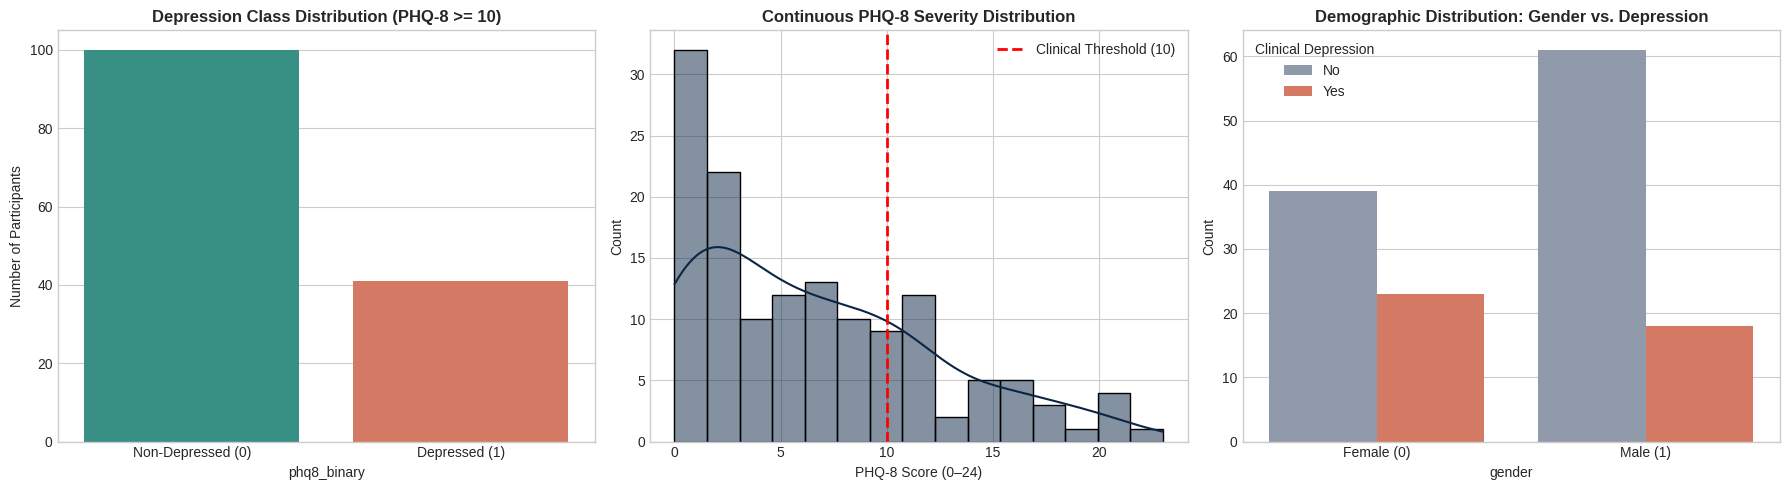

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

print("Generating EDA Dashboard for 115 Validated DAIC-WOZ Sessions...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
        data=df_clean_metadata,
        x='phq8_binary',
        hue='phq8_binary',
        palette=['#2A9D8F', '#E76F51'],
        legend=False,
        ax=axes[0]
)
axes[0].set_title("Depression Class Distribution (PHQ-8 >= 10)", fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Non-Depressed (0)", "Depressed (1)"])
axes[0].set_ylabel("Number of Participants")

sns.histplot(df_clean_metadata['phq8_score'], kde=True, bins=15, color='#0B2545', ax=axes[1])
axes[1].axvline(10, color='red', linestyle='--', linewidth=2, label='Clinical Threshold (10)')
axes[1].set_title("Continuous PHQ-8 Severity Distribution", fontweight='bold')
axes[1].set_xlabel("PHQ-8 Score (0–24)")
axes[1].legend()

sns.countplot(data=df_clean_metadata, x='gender', hue='phq8_binary', palette=['#8D99AE', '#E76F51'], ax=axes[2])
axes[2].set_title("Demographic Distribution: Gender vs. Depression", fontweight='bold')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Female (0)", "Male (1)"])
axes[2].set_ylabel("Count")
axes[2].legend(title="Clinical Depression", labels=["No", "Yes"])

plt.tight_layout()

In [ ]:
print("Starting Visual Modality Pipeline (df_image)...")

visual_records = []
valid_participant_ids = df_clean_metadata['participant_id'].tolist()
target_aus = ['AU01_r', 'AU02_r', 'AU04_r', 'AU06_r', 'AU12_r', 'AU14_r', 'AU15_r']

for participant_id in valid_participant_ids:
    session_dir = os.path.join(UNZIPPED_DATA_DIR, f"{participant_id}_P")
    openface_file = os.path.join(session_dir, f"{participant_id}_CLNF_AUs.txt")

    if os.path.exists(openface_file):
        df_vid = pd.read_csv(openface_file, sep=r',\s*', engine='python')


        if 'success' in df_vid.columns and 'confidence' in df_vid.columns:
            df_valid_frames = df_vid[(df_vid['success'] == 1) & (df_vid['confidence'] >= 0.80)]
        else:
            df_valid_frames = df_vid

        total_frames = len(df_vid)
        valid_frames = len(df_valid_frames)

        if valid_frames > 0:
            session_stats = {'participant_id': participant_id,
                             'total_frames': total_frames,
                             'valid_frames': valid_frames,
                             'tracking_success_rate': valid_frames / total_frames}
            available_aus = [au for au in target_aus if au in df_valid_frames.columns]
            for au in available_aus:
                session_stats[f'{au}_mean'] = df_valid_frames[au].mean()
                session_stats[f'{au}_std'] = df_valid_frames[au].std()
            visual_records.append(session_stats)
        else:
            print(f"Warning: No valid frames found for {participant_id}_P after filtering.")
    else:
        print(f"Warning: OpenFace visual file not found for session {participant_id}_P")

Starting Visual Modality Pipeline (df_image)...


### Label Alignment: Merge ground-truth clinical targets

In [ ]:
df_image = pd.DataFrame(visual_records)
df_image = pd.merge(
    df_image,
    df_clean_metadata[['participant_id', 'phq8_binary', 'phq8_score', 'split_set']],
    on='participant_id',
    how='inner'
)

print("=" * 70)
print("VISUAL EXTRACTION COMPLETE (df_image)")
print("=" * 70)
print(f"Total visual sessions parsed:         {len(df_image)}")
print(f"Average tracking success rate:        {df_image['tracking_success_rate'].mean() * 100:.2f}%")
print("=" * 70)

VISUAL EXTRACTION COMPLETE (df_image)
Total visual sessions parsed:         141
Average tracking success rate:        93.47%


In [ ]:
print("Starting Acoustic Modality Pipeline (df_audio)...")

audio_records = []
valid_participant_ids = df_clean_metadata['participant_id'].tolist()
target_acoustic_features = ['F0', 'NAQ', 'H1H2', 'peakSlope', 'Rd']

for participant_id in valid_participant_ids:
    session_dir = os.path.join(UNZIPPED_DATA_DIR, f"{participant_id}_P")
    covarep_file = os.path.join(session_dir, f"{participant_id}_COVAREP.csv")

    if os.path.exists(covarep_file):

        df_audio_raw = pd.read_csv(covarep_file, header=None)
        df_audio_raw.rename(columns={0: 'F0', 1: 'VUV', 2: 'NAQ', 4: 'H1H2', 6: 'peakSlope', 7: 'Rd'}, inplace=True)
        df_voiced = df_audio_raw[df_audio_raw['VUV'] == 1]
        total_audio_frames = len(df_audio_raw)
        voiced_frames = len(df_voiced)

        if voiced_frames > 0:

            session_stats = {
                'participant_id': participant_id,
                'total_audio_frames': total_audio_frames,
                'voiced_frames': voiced_frames,
                'voiced_ratio': voiced_frames / total_audio_frames
            }

            available_features = [f for f in target_acoustic_features if f in df_voiced.columns]

            for feat in available_features:
                session_stats[f'{feat}_mean'] = df_voiced[feat].mean()
                session_stats[f'{feat}_std'] = df_voiced[feat].std()

            audio_records.append(session_stats)
        else:
            print(f"Warning: No voiced frames found for {participant_id}_P.")
    else:
        print(f"Warning: COVAREP audio file not found for session {participant_id}_P")
df_audio = pd.DataFrame(audio_records)
df_audio = pd.merge(
    df_audio,
    df_clean_metadata[['participant_id', 'phq8_binary', 'phq8_score', 'split_set']],
    on='participant_id',
    how='inner'
)

print("=" * 70)
print("ACOUSTIC EXTRACTION COMPLETE (df_audio)")
print("=" * 70)
print(f"Total audio sessions parsed:         {len(df_audio)}")
print(f"Average voiced speech ratio:         {df_audio['voiced_ratio'].mean() * 100:.2f}%")
print("=" * 70)

Starting Acoustic Modality Pipeline (df_audio)...
ACOUSTIC EXTRACTION COMPLETE (df_audio)
Total audio sessions parsed:         141
Average voiced speech ratio:         36.36%


In [ ]:
print("Starting Linguistic Extraction Pipeline (df_text)...")

text_records = []
valid_participant_ids = df_clean_metadata['participant_id'].tolist()

for participant_id in valid_participant_ids:
    session_dir = os.path.join(UNZIPPED_DATA_DIR, f"{participant_id}_P")
    transcript_file = os.path.join(session_dir, f"{participant_id}_TRANSCRIPT.csv")

    if os.path.exists(transcript_file):
        try:
            df_raw_transcript = pd.read_csv(transcript_file, sep='\t', encoding='utf-8', encoding_errors='ignore')
            df_raw_transcript.columns = df_raw_transcript.columns.str.strip()
            if 'speaker' not in df_raw_transcript.columns:
                print(f"Warning: 'speaker' column not found in {transcript_file}. Skipping participant {participant_id}.")
                continue

            df_participant_turns = df_raw_transcript[df_raw_transcript['speaker'] == 'Participant'].copy()

            if not df_participant_turns.empty:
                raw_combined_text = " ".join(df_participant_turns['value'].astype(str).tolist())
                sanitized_text = re.sub(r'<scrubbed_entry>', '', raw_combined_text)
                sanitized_text = re.sub(r'\s+', ' ', sanitized_text).strip()

                text_records.append({
                    'participant_id': participant_id,
                    'clean_transcript': sanitized_text,
                    'word_count': len(sanitized_text.split())
                })
            else:
                print(f"Warning: No 'Participant' turns found in {transcript_file}. Skipping participant {participant_id}.")
        except pd.errors.EmptyDataError:
            print(f"Warning: Transcript file {transcript_file} is empty. Skipping participant {participant_id}.")
        except Exception as e:
            # Catch any other parsing errors
            print(f"Error processing {transcript_file} for participant {participant_id}: {e}. Skipping.")
    else:
        print(f"Warning: Transcript file not found for session {participant_id}_P")
df_text = pd.DataFrame(text_records)
df_text = pd.merge(
    df_text,
    df_clean_metadata[['participant_id', 'phq8_binary', 'phq8_score', 'gender', 'split_set']],
    on='participant_id',
    how='inner'
)

print("=" * 70)
print("LINGUISTIC EXTRACTION COMPLETE (df_text)")
print("=" * 70)
print(f"Total transcripts parsed:      {len(df_text)}")
print("=" * 70)


Starting Linguistic Extraction Pipeline (df_text)...
LINGUISTIC EXTRACTION COMPLETE (df_text)
Total transcripts parsed:      139


In [ ]:
print("Consolidating Modalities into Master Stacking Matrix...")
df_master = df_clean_metadata[['participant_id', 'gender', 'phq8_binary', 'phq8_score', 'split_set']].copy()
text_cols = [col for col in df_text.columns if col not in ['phq8_binary', 'phq8_score', 'split_set', 'gender']]
df_master = pd.merge(df_master, df_text[text_cols], on='participant_id', how='inner')
image_cols = [col for col in df_image.columns if col not in ['phq8_binary', 'phq8_score', 'split_set', 'gender']]
df_master = pd.merge(df_master, df_image[image_cols], on='participant_id', how='inner')
audio_cols = [col for col in df_audio.columns if col not in ['phq8_binary', 'phq8_score', 'split_set', 'gender']]
df_master = pd.merge(df_master, df_audio[audio_cols], on='participant_id', how='inner')
OUTPUT_PATH = "/content/drive/MyDrive/Thesis/Dataset/results_master_stacked.csv"
df_master.to_csv(OUTPUT_PATH, index=False)
print("=" * 70)
print("MASTER STACKING MATRIX SAVED")
print("=" * 70)
print(f"Final Dataset Shape: {df_master.shape[0]} rows (sessions), {df_master.shape[1]} columns (features)")
print(f"Saved successfully to: {OUTPUT_PATH}")
print("=" * 70)

Consolidating Modalities into Master Stacking Matrix...
MASTER STACKING MATRIX SAVED
Final Dataset Shape: 139 rows (sessions), 37 columns (features)
Saved successfully to: /content/drive/MyDrive/Thesis/Dataset/results_master_stacked.csv


## Pipeline Summary

This notebook has successfully processed the DAIC-WOZ dataset. It ingested and cleaned metadata, audited physical session folders, and extracted features from visual (OpenFace), acoustic (COVAREP), and linguistic (transcript) modalities. Finally, all extracted features were consolidated into a single master DataFrame (`df_master`) and saved as a CSV file, ready for further analysis and model training.